# Features Pipeline
## FROM SMILES TO  MACCS + Morgan + Mordred descriptors

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem, rdFingerprintGenerator, DataStructs
from rdkit.Chem.Draw import MolsToGridImage
from mordred import Calculator, descriptors

sns.set_theme(style='whitegrid', font_scale=1.05)
COLORS = ['#534AB7', '#0F6E56', '#993C1D', '#BA7517', '#378ADD', '#888780']

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.25.2 and <2.6.0 is required for this version of SciPy (detected version 1.24.4)
  from scipy.stats import gaussian_kde


## 1. Config

In [2]:
INPUT_FILE    = r"c:\Users\hp\Desktop\stage etis\dataset\7Q27.normalized.signatures.csv"
OUTPUT_FILE   = r"c:\Users\hp\Desktop\stage etis\dataset\dataset_all_features_plots.csv"

EXCLUDED_ITEMS  = {"Blanc_080426", "allumage_080426"}
NAN_THRESHOLD   = 0.20
CORR_THRESHOLD  = 0.95
MORGAN_RADIUS   = 2
MORGAN_NBITS    = 512

# Clean display names used in all plots
DISPLAY_NAMES = {
    'Ocimene_080426':        'Ocimene',
    'Delta 3 Carene_080426': 'Δ3-Carene',
    'Linalol_080426':        'Linalool',
    'A Pinene_080426':       'α-Pinene',
    'S limonene_080426':     'S-Limonene',
    'R limonene_080426':     'R-Limonene',
}

SENSOR_COLS = ['1', '105', '106', '24', '25', '34', '36', '55']

## 2. SMILES Fetching (PubChem)

In [3]:
# hna anmappiw names dyal lmolecule li machi nfsoum fdictionnaire dyal names li kayn f api of pubchem

names_map = {
    "A-Pinene": "Alpha-Pinene",
    "S-limonene": "(-)-Limonene",
    "R-limonene": "(+)-Limonene"
}


def clean_name(name):
    base_name = name.split('_')[0].strip()
    base_name = base_name.replace(" ", "-")
    pubchem_name = names_map.get(base_name, base_name)
    return pubchem_name


def get_smiles(name):
    """Fetches SMILES from PubChem."""
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/property/IsomericSMILES/JSON"
    r = requests.get(url)
    if r.status_code == 200:
        return r.json()['PropertyTable']['Properties'][0]['SMILES']
    return None

In [4]:
df = pd.read_csv(INPUT_FILE, sep=';')
unique_items = df['item'].unique()

smiles_mapping = {}

for raw_item in unique_items:
    if 'blanc' in raw_item.lower() or 'allumage' in raw_item.lower():
        continue

    search_name = clean_name(raw_item)
    smiles = get_smiles(search_name)
    smiles_mapping[raw_item] = smiles

    if smiles:
        print(f"Success | Raw: {raw_item:<20} | Searched: {search_name:<15} | SMILES: {smiles}")
    else:
        print(f"Failed  | Raw: {raw_item:<20} | Searched: {search_name:<15}")

    time.sleep(0.2)

df['SMILES'] = df['item'].map(smiles_mapping)

print(f"\nSMILES fetched for {df['SMILES'].notna().sum()}/{len(df)} rows")
print(df[['item', 'SMILES']].drop_duplicates())

Success | Raw: Ocimene_080426       | Searched: Ocimene         | SMILES: CC(C)/C=C/C=C(\C)/C=C
Success | Raw: Delta 3 Carene_080426 | Searched: Delta-3-Carene  | SMILES: CC1=CCC2C(C1)C2(C)C
Success | Raw: Linalol_080426       | Searched: Linalol         | SMILES: CC(=CCCC(C)(C=C)O)C
Success | Raw: A Pinene_080426      | Searched: Alpha-Pinene    | SMILES: CC1=CCC2CC1C2(C)C
Success | Raw: S limonene_080426    | Searched: (-)-Limonene    | SMILES: CC1=CC[C@H](CC1)C(=C)C
Success | Raw: R limonene_080426    | Searched: (+)-Limonene    | SMILES: CC1=CC[C@@H](CC1)C(=C)C

SMILES fetched for 18/21 rows
                     item                   SMILES
0          Ocimene_080426    CC(C)/C=C/C=C(\C)/C=C
3   Delta 3 Carene_080426      CC1=CCC2C(C1)C2(C)C
6          Linalol_080426      CC(=CCCC(C)(C=C)O)C
9         A Pinene_080426        CC1=CCC2CC1C2(C)C
12      S limonene_080426   CC1=CC[C@H](CC1)C(=C)C
15      R limonene_080426  CC1=CC[C@@H](CC1)C(=C)C
18           Blanc_080426               

###  2D Molecular Structures


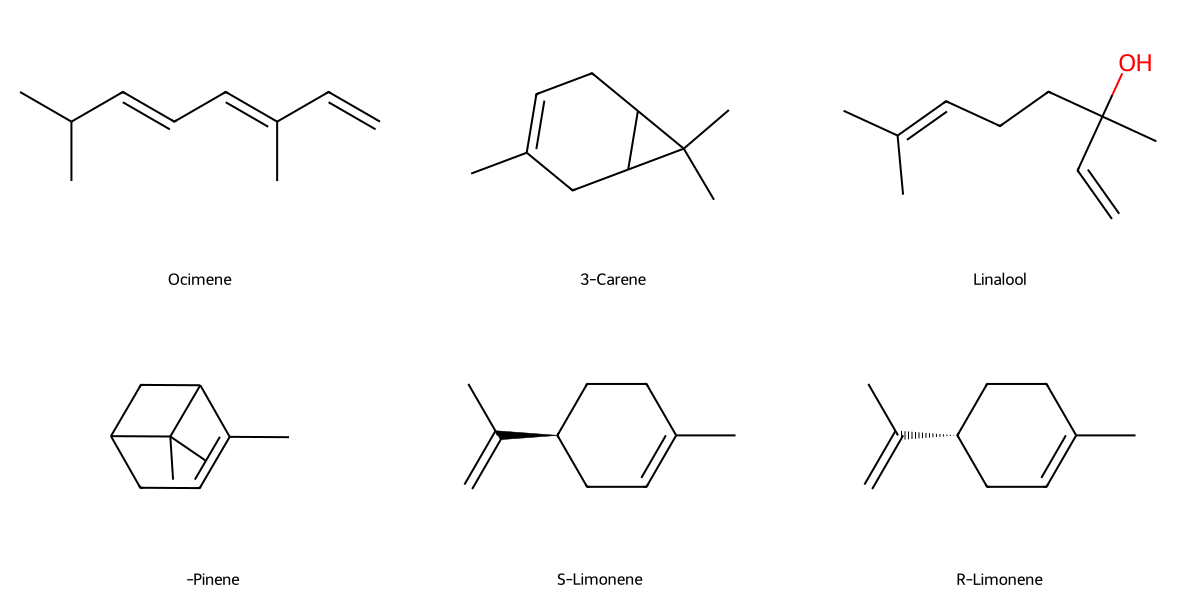

In [5]:
df_clean = df[~df['item'].isin(EXCLUDED_ITEMS) & df['SMILES'].notna()].copy()
unique_smiles = df_clean[['item', 'SMILES']].drop_duplicates(subset='SMILES').reset_index(drop=True)

mols   = [Chem.MolFromSmiles(s) for s in unique_smiles['SMILES']]
labels = [DISPLAY_NAMES.get(it, it) for it in unique_smiles['item']]

img = MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(400, 300),
    legends=labels,
)

img

## 3. MACCS Fingerprints

In [6]:
def smiles_to_maccs(smiles):
    # in the documentation they work with objects of the rdchem.Mol class so nconvertiwha lobjects dyal dik lclass
    mol = Chem.MolFromSmiles(smiles)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)

In [7]:
print("Computing MACCS fingerprints for each unique molecule:\n")
maccs_data = []

for s in unique_smiles['SMILES']:
    bits = smiles_to_maccs(s)
    if bits:
        entry = {'SMILES': s}
        entry.update({f'MACCS_{i:03d}': bits[i] for i in range(1, 167)})
        maccs_data.append(entry)

maccs_df = pd.DataFrame(maccs_data)
print(f"MACCS done: {len(maccs_df)} molecules × {len(maccs_df.columns)-1} bits")

Computing MACCS fingerprints for each unique molecule:

MACCS done: 6 molecules × 166 bits


### Plot :  MACCS Active Bits Heatmap


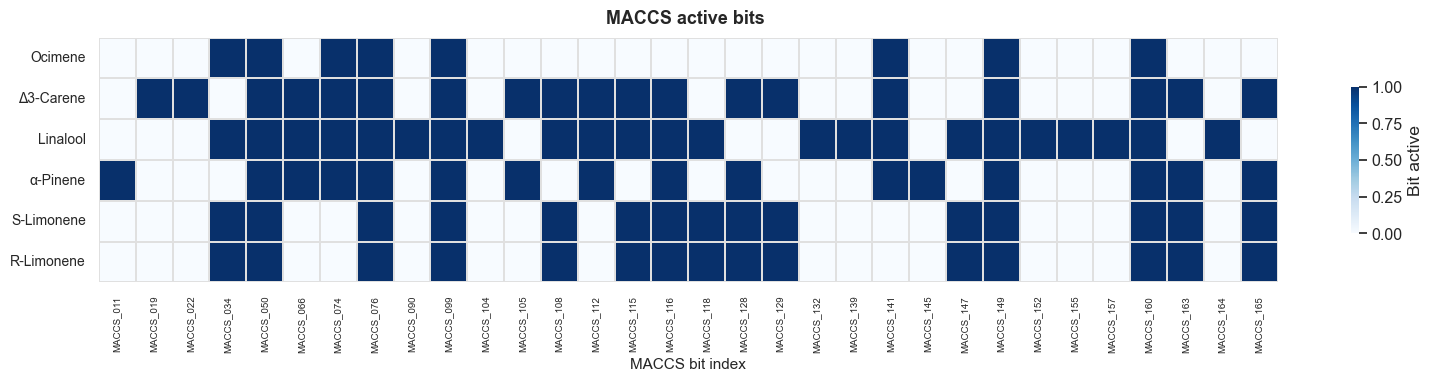

Active bits shown: 32 / 166


In [8]:
maccs_bit_cols = [c for c in maccs_df.columns if c.startswith('MACCS_')]

#Bax n5aliw 4i les bits actifs f les molecules bach nchoufo chmn bit kaydistinguish les molecules
maccs_active = maccs_df[maccs_bit_cols].loc[:, maccs_df[maccs_bit_cols].any()]
maccs_plot_df = maccs_active.copy()
maccs_plot_df.index = labels

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    maccs_plot_df,
    ax=ax,
    cmap='Blues',
    linewidths=0.3,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Bit active', 'shrink': 0.6},
    xticklabels=True,
    yticklabels=True,
)
ax.set_title('MACCS active bits ', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('MACCS bit index', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
plt.show()

print(f"Active bits shown: {maccs_active.shape[1]} / 166")

## 4. Morgan Fingerprints

In [9]:
unique_mols = df_clean[['item', 'SMILES']].drop_duplicates().dropna(subset=['SMILES'])

generator = rdFingerprintGenerator.GetMorganGenerator(radius=MORGAN_RADIUS, fpSize=MORGAN_NBITS, includeChirality=True)

fp_records    = []
morgan_fps_raw = []  # keep raw fingerprint objects for Tanimoto

for _, row in unique_mols.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        bits = list(generator.GetFingerprintAsNumPy(mol))
        feature_dict = {f'morgan_{i}': val for i, val in enumerate(bits)}
        feature_dict['SMILES'] = row['SMILES']
        fp_records.append(feature_dict)
        morgan_fps_raw.append(generator.GetFingerprint(mol))

morgan_df = pd.DataFrame(fp_records)
print(f"Morgan done: {len(morgan_df)} molecules × {MORGAN_NBITS} bits")

Morgan done: 6 molecules × 512 bits


### Plot:Tanimoto Similarity Matrix for the Morgan
 0 = nothing in common, 1 = identical.


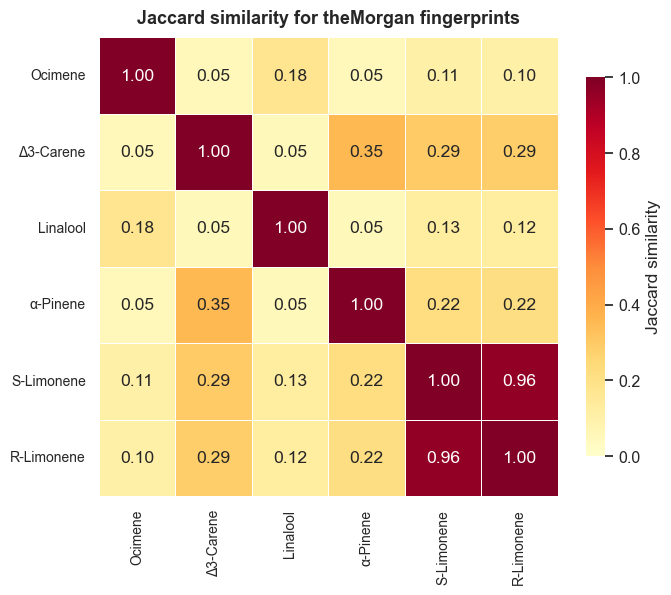

In [21]:
n = len(morgan_fps_raw)
tanimoto_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        tanimoto_matrix[i, j] = DataStructs.TanimotoSimilarity(morgan_fps_raw[i], morgan_fps_raw[j])

tanimoto_df = pd.DataFrame(tanimoto_matrix, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    tanimoto_df,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Jaccard similarity', 'shrink': 0.8},
)
ax.set_title('Jaccard similarity for theMorgan fingerprints',
             fontsize=13, fontweight='bold', pad=10)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

## 5. Mordred Descriptors

In [11]:
def smiles_to_3d_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    result = AllChem.EmbedMolecule(mol, randomSeed=42)
    if result == -1:
        return None
    AllChem.MMFFOptimizeMolecule(mol)
    mol = Chem.RemoveHs(mol)
    return mol

In [12]:
calc = Calculator(descriptors, ignore_3D=False)

mordred_rows = []
for _, row in unique_smiles.iterrows():
    mol = smiles_to_3d_mol(row['SMILES'])
    if mol is None:
        print(f"  WARNING: 3D embedding failed for {row['item']} → {row['SMILES']}")
        mordred_rows.append({'SMILES': row['SMILES']})
        continue
    result = calc(mol)
    desc_dict = {str(k): v for k, v in result.items()}
    desc_dict['SMILES'] = row['SMILES']
    mordred_rows.append(desc_dict)

mordred_df  = pd.DataFrame(mordred_rows)
desc_cols   = [c for c in mordred_df.columns if c != 'SMILES']
mordred_df[desc_cols] = mordred_df[desc_cols].apply(pd.to_numeric, errors='coerce')

print(f"Raw Mordred descriptors: {len(desc_cols)}")

Raw Mordred descriptors: 1826


### Filtering

#### Dropping descriptors with too many NaN values

In [13]:
n_raw = len(desc_cols)

nan_frac = mordred_df[desc_cols].isna().mean()
keep = nan_frac[nan_frac <= NAN_THRESHOLD].index.tolist()
dropped_nan = len(desc_cols) - len(keep)
print(f"Dropped (>{NAN_THRESHOLD*100:.0f}% NaN):       {dropped_nan}")
desc_cols   = keep
n_after_nan = len(desc_cols)

# for the ones left with little Nan values i replaced the Nan with the median
mordred_df[desc_cols] = mordred_df[desc_cols].fillna(mordred_df[desc_cols].median())

Dropped (>20% NaN):       386


#### Dropping descriptors with 0 variance

In [14]:
variance = mordred_df[desc_cols].var()
keep = variance[variance > 0].index.tolist()
dropped_var = len(desc_cols) - len(keep)
print(f"Dropped (zero variance):      {dropped_var}")
desc_cols   = keep
n_after_var = len(desc_cols)

Dropped (zero variance):      352


#### Dropping highly correlated descriptor pairs

In [15]:
corr_matrix = mordred_df[desc_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop   = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
desc_cols = [c for c in desc_cols if c not in to_drop]
n_final   = len(desc_cols)
print(f"Dropped (corr > {CORR_THRESHOLD}):     {len(to_drop)}")
print(f"Final Mordred descriptor count:       {n_final}")

Dropped (corr > 0.95):     1040
Final Mordred descriptor count:       48


### Plot: Final Mordred Descriptors Heatmap
Values are z-score normalized per column so differences across molecules are visible
regardless of the original scale of each descriptor.


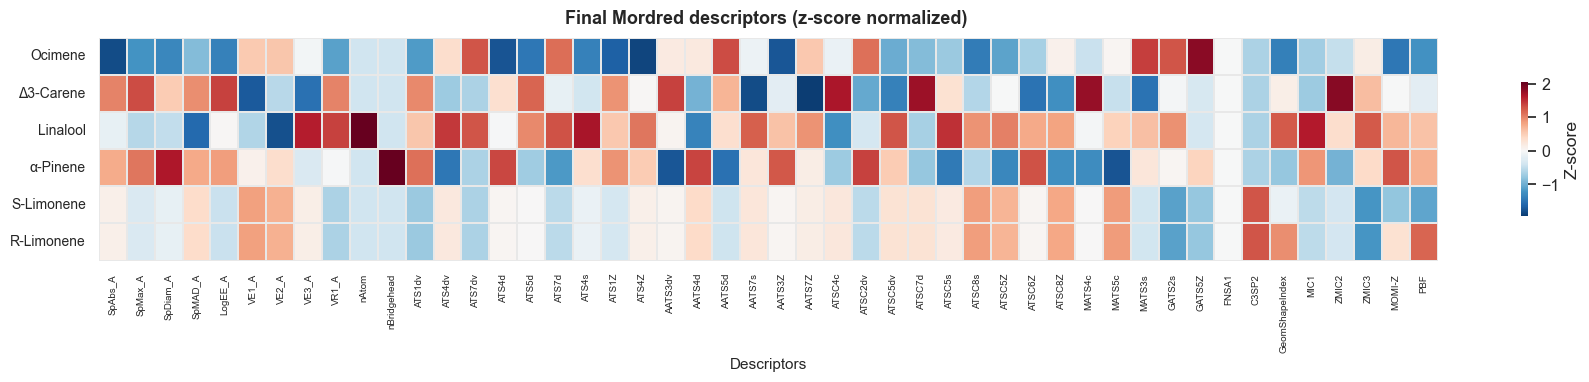

In [16]:
mordred_clean = mordred_df[['SMILES'] + desc_cols].copy()
mordred_plot  = mordred_clean[desc_cols].copy()
mordred_plot.index = labels

# Z-score normalize per column
mordred_norm = (mordred_plot - mordred_plot.mean()) / (mordred_plot.std() + 1e-8)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    mordred_norm,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    linewidths=0.2,
    linecolor='#e8e8e8',
    cbar_kws={'label': 'Z-score', 'shrink': 0.6},
    xticklabels=True,
    yticklabels=True,
)
ax.set_title(
    f'Final Mordred descriptors (z-score normalized) ',
    fontsize=13, fontweight='bold', pad=10
)
ax.set_xlabel('Descriptors', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
plt.show()

## 6. Merge All Features & Save

In [17]:
result_df = df.merge(maccs_df,      on='SMILES', how='left')
result_df = result_df.merge(morgan_df,     on='SMILES', how='left')
result_df = result_df.merge(mordred_clean, on='SMILES', how='left')

result_df.to_csv(OUTPUT_FILE, index=False, sep=';')

print(f"\nSaved to: {OUTPUT_FILE}")


Saved to: c:\Users\hp\Desktop\stage etis\dataset\dataset_all_features_plots.csv


## 7. Exploratory Plots on Sensor Responses

### Plot :  Sensor Response Heatmap
Mean sensor response per substance per sensor channel.


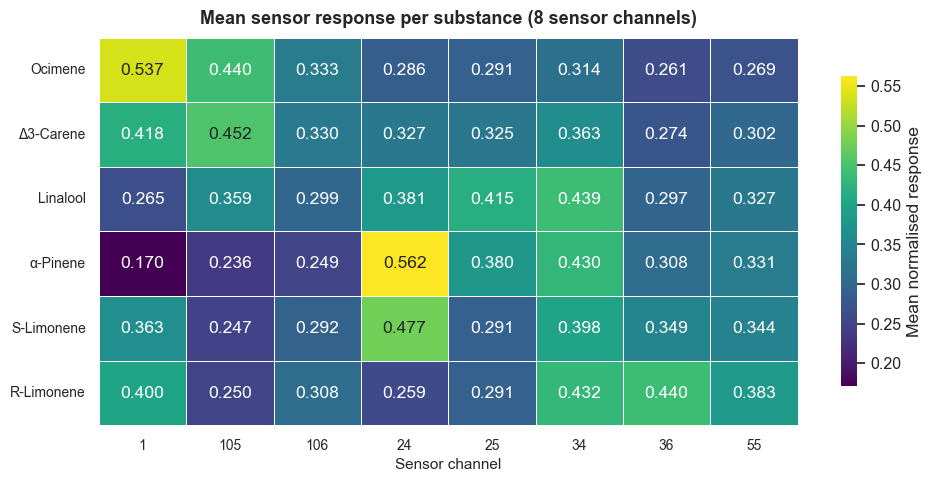

In [18]:
sensor_df = result_df[
    ~result_df['item'].isin(EXCLUDED_ITEMS) & result_df['SMILES'].notna()
].copy()

sensor_df['display_name'] = sensor_df['item'].map(DISPLAY_NAMES)
sensor_mean = sensor_df.groupby('display_name')[SENSOR_COLS].mean()

# Preserve the order defined in DISPLAY_NAMES
ordered_names = [v for v in DISPLAY_NAMES.values() if v in sensor_mean.index]
sensor_mean   = sensor_mean.loc[ordered_names]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    sensor_mean,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap='viridis',
    linewidths=0.4,
    cbar_kws={'label': 'Mean normalised response', 'shrink': 0.8},
)
ax.set_title('Mean sensor response per substance (8 sensor channels)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Sensor channel', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

### Plot: Sensor Response Radar Chart
Each line is one substance. The radar view makes it easy to spot which sensors are most
discriminative and which substances have overlapping response profiles.

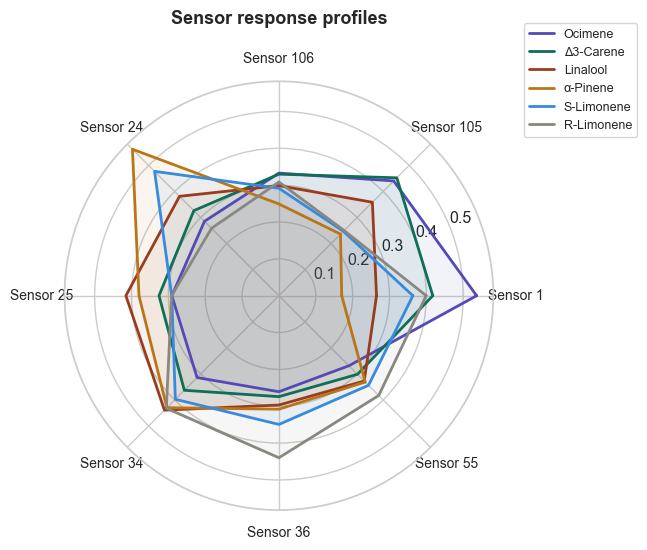

In [19]:
N      = len(SENSOR_COLS)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for idx, (mol_name, row) in enumerate(sensor_mean.iterrows()):
    values  = row[SENSOR_COLS].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid',
            label=mol_name, color=COLORS[idx])
    ax.fill(angles, values, alpha=0.07, color=COLORS[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f'Sensor {s}' for s in SENSOR_COLS], fontsize=10)
ax.set_title('Sensor response profiles',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()